In [17]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

We set up the global variables

In [18]:
CSV_FOLDER = Path(r"C:\Users\david\Desktop\Results\datos_csv") 

csv_files = list(CSV_FOLDER.glob('*.csv'))

In [19]:
csv_files[0].name

'flat_pinpoint_103_landmarks.csv'

In [20]:
df = pd.read_csv(csv_files[0])
df

,frame_id,NOSE_x,NOSE_y,NOSE_z,NOSE_v,LEFT_EYE_INNER_x,LEFT_EYE_INNER_y,LEFT_EYE_INNER_z,LEFT_EYE_INNER_v,LEFT_EYE_x,...,RIGHT_HEEL_z,RIGHT_HEEL_v,LEFT_FOOT_INDEX_x,LEFT_FOOT_INDEX_y,LEFT_FOOT_INDEX_z,LEFT_FOOT_INDEX_v,RIGHT_FOOT_INDEX_x,RIGHT_FOOT_INDEX_y,RIGHT_FOOT_INDEX_z,RIGHT_FOOT_INDEX_v
0,0,0.618584,0.560035,0.108327,0.999994,0.620250,0.550632,0.115618,0.999988,0.619560,...,-0.159092,0.997644,0.602438,0.911301,-0.037961,0.998056,0.548409,0.923169,-0.213649,0.999227
1,1,0.618671,0.560033,0.158236,0.999995,0.620233,0.550600,0.170185,0.999989,0.619547,...,-0.202661,0.997871,0.602772,0.910227,-0.038020,0.998227,0.553170,0.934109,-0.268646,0.999300
2,2,0.618656,0.559878,0.172400,0.999995,0.620189,0.550297,0.184535,0.999990,0.619517,...,-0.184839,0.998070,0.602928,0.909933,-0.014833,0.998362,0.555063,0.938693,-0.250482,0.999363
3,3,0.618715,0.560064,0.169919,0.999996,0.620238,0.550382,0.182416,0.999991,0.619576,...,-0.205802,0.998250,0.603591,0.910412,-0.021929,0.998485,0.556529,0.940750,-0.276532,0.999420
4,4,0.618716,0.560573,0.171669,0.999996,0.620264,0.550561,0.184115,0.999992,0.619608,...,-0.193805,0.998401,0.600792,0.909784,-0.034002,0.998489,0.560655,0.942082,-0.264241,0.999456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,247,0.509441,0.536237,0.091663,0.999302,0.507783,0.530106,0.077975,0.998891,0.506498,...,0.007716,0.852409,0.521004,0.873448,-0.083502,0.763209,0.528931,0.870921,0.004568,0.532089
248,248,0.508822,0.532570,0.097721,0.999315,0.507065,0.526912,0.084605,0.998922,0.505677,...,0.002835,0.850840,0.516394,0.872262,-0.089459,0.743013,0.528614,0.872905,-0.004093,0.519050
249,249,0.508683,0.529115,0.091067,0.999358,0.506780,0.523585,0.077919,0.998997,0.505378,...,0.006811,0.854670,0.514559,0.872441,-0.111019,0.744968,0.527056,0.871340,-0.002388,0.519952
250,250,0.508394,0.525776,0.075033,0.999417,0.506204,0.520138,0.061732,0.999092,0.504670,...,0.005133,0.857984,0.514090,0.874325,-0.102931,0.748964,0.527276,0.870392,-0.001948,0.526044


🎯 DATO CLAVE: La máxima flexión de rodilla ocurre en el Frame 114


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

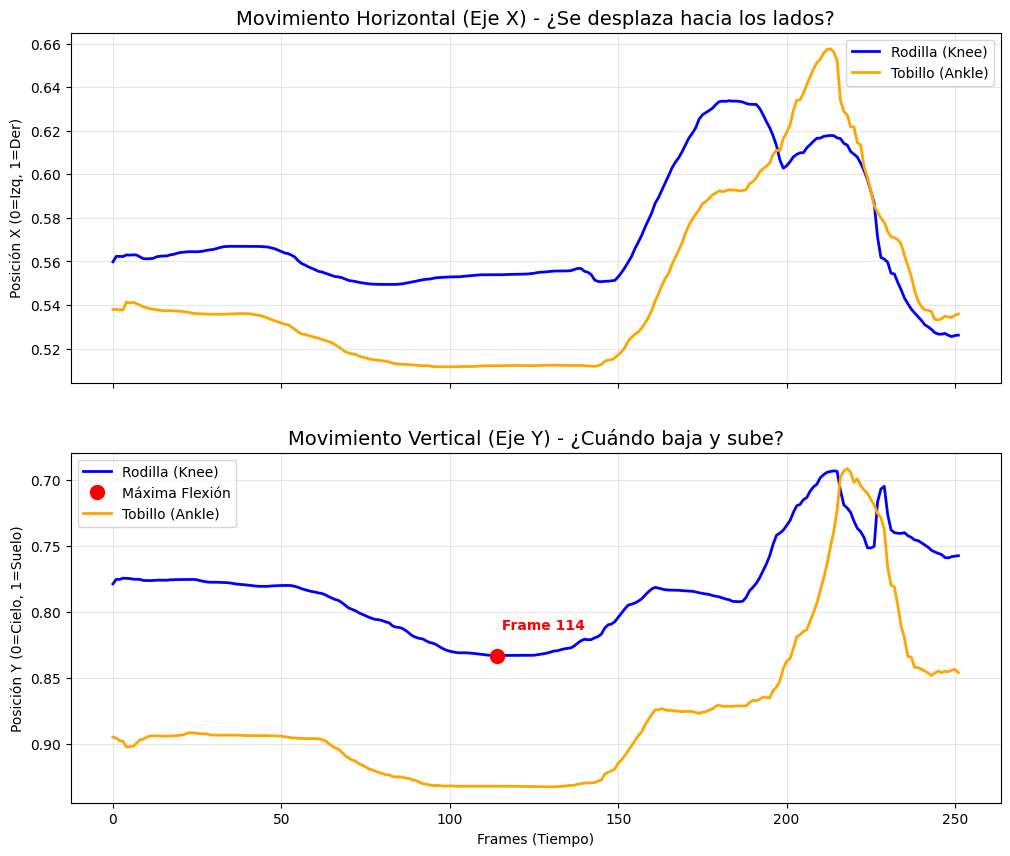

In [21]:
# --- 3. SELECCIÓN DE DATOS ---
# Elegimos el lado DERECHO (RIGHT) suponiendo que es diestro.
# Si fuera zurdo, cambia "RIGHT" por "LEFT".
parts = {
    "Rodilla (Knee)": ("RIGHT_KNEE_x", "RIGHT_KNEE_y"),
    "Tobillo (Ankle)": ("RIGHT_ANKLE_x", "RIGHT_ANKLE_y")
}

# --- 4. VISUALIZACIÓN ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# COLORES
colors = {'Rodilla (Knee)': 'blue', 'Tobillo (Ankle)': 'orange'}

for label, (col_x, col_y) in parts.items():
    if col_x in df.columns and col_y in df.columns:
        # Gráfica X (Movimiento Lateral)
        ax1.plot(df['frame_id'], df[col_x], label=label, color=colors[label], linewidth=2)
        
        # Gráfica Y (Movimiento Vertical / Altura)
        ax2.plot(df['frame_id'], df[col_y], label=label, color=colors[label], linewidth=2)
        
        # --- DETECCIÓN AUTOMÁTICA: MÁXIMA FLEXIÓN ---
        # En MediaPipe: Y=0 es Arriba, Y=1 es Abajo (Suelo).
        # Por tanto, el valor MÁXIMO de Y es el punto MÁS BAJO (Máxima Flexión).
        if "Rodilla" in label:
            max_flex_idx = df[col_y].idxmax() # Índice del valor máximo
            max_flex_val = df[col_y].max()    # Valor máximo
            
            # Pintamos un punto rojo en ese momento
            ax2.plot(max_flex_idx, max_flex_val, 'ro', markersize=10, label='Máxima Flexión')
            ax2.text(max_flex_idx, max_flex_val - 0.02, f' Frame {max_flex_idx}', color='red', fontweight='bold')
            
            print(f"🎯 DATO CLAVE: La máxima flexión de rodilla ocurre en el Frame {max_flex_idx}")

# --- 5. MAQUILLAJE DE LA GRÁFICA ---

# Gráfica 1: Eje X (Lateral)
ax1.set_title("Movimiento Horizontal (Eje X) - ¿Se desplaza hacia los lados?", fontsize=14)
ax1.set_ylabel("Posición X (0=Izq, 1=Der)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfica 2: Eje Y (Vertical)
ax2.set_title("Movimiento Vertical (Eje Y) - ¿Cuándo baja y sube?", fontsize=14)
ax2.set_ylabel("Posición Y (0=Cielo, 1=Suelo)")
ax2.grid(True, alpha=0.3)
ax2.legend()

# IMPORTANTE: Invertimos el eje Y para que sea intuitivo
# Así, si la línea baja en la gráfica, es que el jugador baja (se agacha).
# Si la línea sube, el jugador salta.
ax2.invert_yaxis()

plt.xlabel("Frames (Tiempo)")
plt.tight_layout

In [24]:
# Cargar tu CSV
CSV_PATH = Path(r"C:\Users\david\Desktop\Results\datos_csv\flat_platform_51_landmarks.csv") # Ajusta si es otro video
df = pd.read_csv(CSV_PATH)

# 1. ENCONTRAR EL FRAME DE MÁXIMA FLEXIÓN (EL "CUÁNDO")
# Buscamos el valor MÁXIMO en Y de la rodilla derecha (Y=1 es suelo)
knee_col = 'RIGHT_KNEE_y'
max_flex_frame = df[knee_col].idxmax()
print(f"⏱️ Momento de carga máxima (Golden Frame): {max_flex_frame}")

# 2. SACAR LA "FOTO" EN ESE FRAME
row = df.iloc[max_flex_frame]

# 3. CALCULAR DISTANCIAS (EL "QUÉ")
# A. Ancho de Caderas (Nuestra regla de medir)
hip_width = abs(row['LEFT_HIP_x'] - row['RIGHT_HIP_x'])

# B. Distancia entre Tobillos (En ese momento)
ankle_dist = abs(row['LEFT_ANKLE_x'] - row['RIGHT_ANKLE_x'])

# C. Desplazamiento del pie derecho (Desde el inicio hasta ahora)
# Asumimos frame 0 como inicio.
row_start = df.iloc[0]
foot_drag_dist = abs(row['RIGHT_ANKLE_x'] - row_start['RIGHT_ANKLE_x'])

# 4. RESULTADOS NORMALIZADOS (RATIOS)
ratio_distancia = ankle_dist / hip_width
ratio_arrastre = foot_drag_dist / hip_width

print("-" * 30)
print(f"📏 Ancho de Cadera (Referencia): {hip_width:.4f}")
print("-" * 30)
print(f"🦶 Distancia Tobillos: {ankle_dist:.4f}")
print(f"📊 RATIO DISTANCIA (Tobillos/Cadera): {ratio_distancia:.2f}")
print("-" * 30)
print(f"slider Desplazamiento Pie Der: {foot_drag_dist:.4f}")
print(f"🚀 RATIO ARRASTRE (Desplazamiento/Cadera): {ratio_arrastre:.2f}")
print("-" * 30)

# LÓGICA DE DECISIÓN (Borrador)
if ratio_arrastre > 0.5 or ratio_distancia < 0.6:
    print("🤖 PREDICCIÓN: PINPOINT (Pies juntos o Arrastre)")
else:
    print("🤖 PREDICCIÓN: PLATFORM (Pies separados y quietos)")

⏱️ Momento de carga máxima (Golden Frame): 175
------------------------------
📏 Ancho de Cadera (Referencia): 0.0147
------------------------------
🦶 Distancia Tobillos: 0.0503
📊 RATIO DISTANCIA (Tobillos/Cadera): 3.42
------------------------------
slider Desplazamiento Pie Der: 0.0171
🚀 RATIO ARRASTRE (Desplazamiento/Cadera): 1.16
------------------------------
🤖 PREDICCIÓN: PINPOINT (Pies juntos o Arrastre)


✅ Cargado: flat_pinpoint_103_landmarks.csv

🎯 MOMENTO CLAVE DETECTADO:
   Frame: 114
   Valor Y: 0.8328 (Cuanto más cerca de 1, más cerca del suelo)


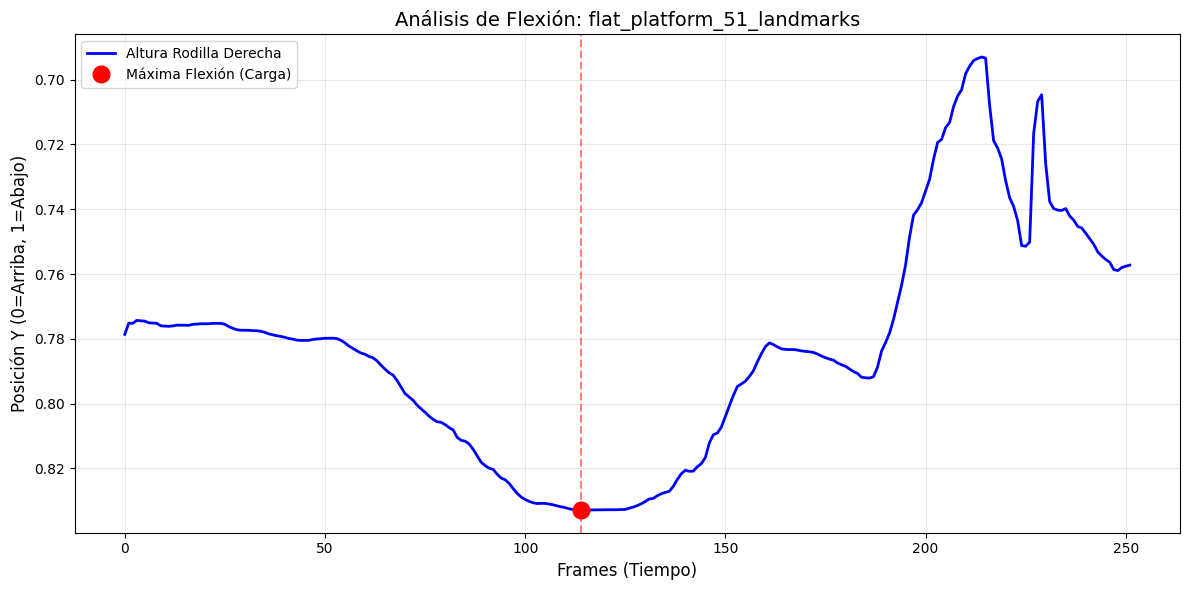

In [25]:
try:
    df = pd.read_csv(csv_files[0])
    print(f"✅ Cargado: {csv_files[0].name}")
except:
    print("❌ Error: No encuentro el archivo. Revisa la ruta.")
    exit()

# --- 3. ANÁLISIS DE LA RODILLA DERECHA (Eje Y) ---
col_name = 'RIGHT_KNEE_y'

# Buscamos el valor MÁXIMO numérico (que es el punto más BAJO físicamente)
# idxmax() nos da el número de frame donde ocurre
frame_max_flexion = df[col_name].idxmax()
valor_max_flexion = df[col_name].max()

print(f"\n🎯 MOMENTO CLAVE DETECTADO:")
print(f"   Frame: {frame_max_flexion}")
print(f"   Valor Y: {valor_max_flexion:.4f} (Cuanto más cerca de 1, más cerca del suelo)")

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))

# Pintamos la línea azul
plt.plot(df['frame_id'], df[col_name], label='Altura Rodilla Derecha', color='blue', linewidth=2)

# Pintamos el punto rojo en el máximo
plt.plot(frame_max_flexion, valor_max_flexion, 'ro', markersize=12, label='Máxima Flexión (Carga)')

# Etiquetas y Decoración
plt.title(f"Análisis de Flexión: {CSV_PATH.stem}", fontsize=14)
plt.xlabel("Frames (Tiempo)", fontsize=12)
plt.ylabel("Posición Y (0=Arriba, 1=Abajo)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# --- TRUCO VISUAL ---
# Invertimos el eje Y para que en la gráfica "Bajar" signifique "Agacharse"
plt.gca().invert_yaxis()

# Dibujamos una línea vertical para ver claro el corte
plt.axvline(x=frame_max_flexion, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

🟢 MÁXIMA FLEXIÓN (Carga): Frame 226 | Ángulo: 11.7°
🟣 MÁXIMA EXTENSIÓN (Vuelo): Frame 251 | Ángulo: 170.3°


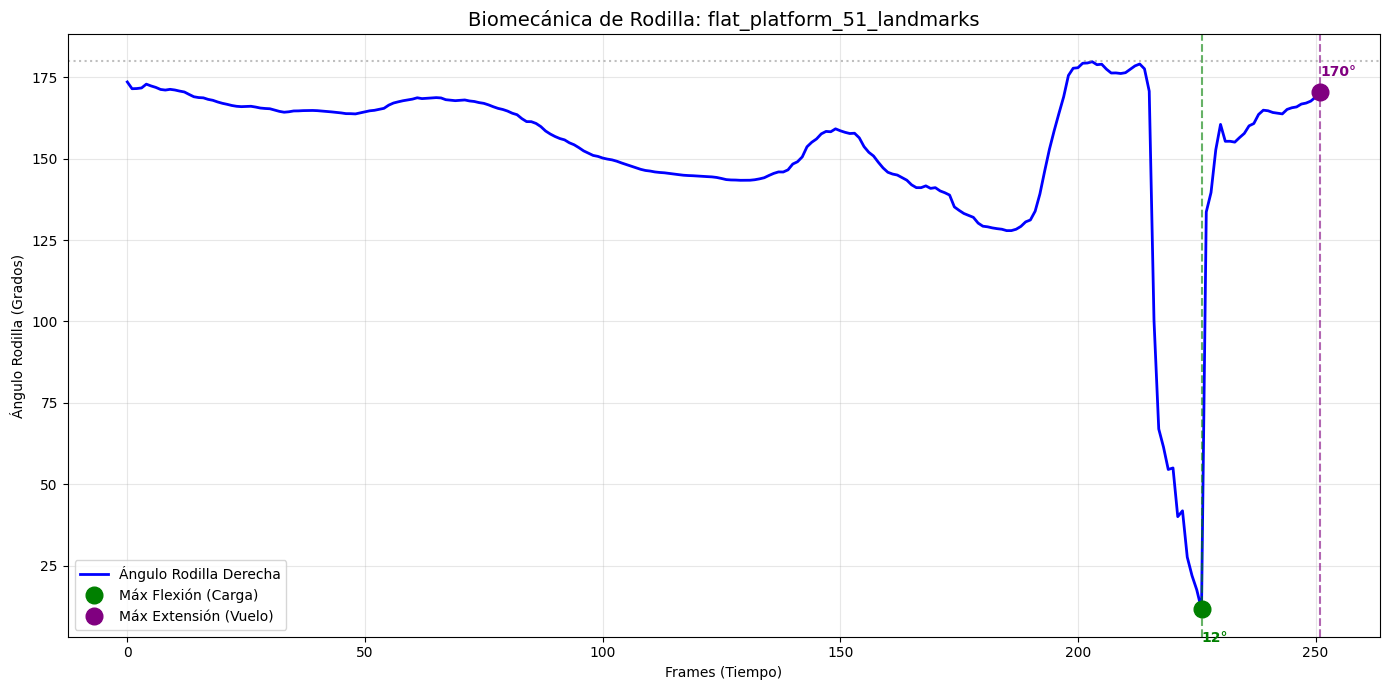

In [26]:
# --- 1. CONFIGURA TU ARCHIVO AQUÍ ---
# --- 2. FUNCIONES MATEMÁTICAS (Para calcular ángulos) ---
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b) # Vértice (Rodilla)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

# --- 3. CARGAR Y PROCESAR ---
try:
    df = pd.read_csv(csv_files[0])
except:
    print("❌ Error: No encuentro el archivo.")
    exit()

# A. Calcular Ángulos de Rodilla Frame a Frame
knee_angles = []
for _, row in df.iterrows():
    hip = [row['RIGHT_HIP_x'], row['RIGHT_HIP_y']]
    knee = [row['RIGHT_KNEE_x'], row['RIGHT_KNEE_y']]
    ankle = [row['RIGHT_ANKLE_x'], row['RIGHT_ANKLE_y']]
    knee_angles.append(calculate_angle(hip, knee, ankle))

df['knee_angle'] = knee_angles

# --- 4. DETECCIÓN DE EVENTOS ---

# EVENTO 1: MÁXIMA FLEXIÓN (CARGA)
# Buscamos el ángulo MÍNIMO (rodilla más doblada)
frame_max_flexion = df['knee_angle'].idxmin()
valor_max_flexion = df['knee_angle'].min()

# EVENTO 2: VUELO (EXTENSIÓN)
# Buscamos el momento de máxima extensión (ángulo cercano a 180) DESPUÉS de la flexión
# Filtramos solo los frames posteriores a la carga
df_flight = df.iloc[frame_max_flexion:] 
frame_max_extension = df_flight['knee_angle'].idxmax()
valor_max_extension = df_flight['knee_angle'].max()

print(f"🟢 MÁXIMA FLEXIÓN (Carga): Frame {frame_max_flexion} | Ángulo: {valor_max_flexion:.1f}°")
print(f"🟣 MÁXIMA EXTENSIÓN (Vuelo): Frame {frame_max_extension} | Ángulo: {valor_max_extension:.1f}°")

# --- 5. VISUALIZACIÓN ---
plt.figure(figsize=(14, 7))

# Pintamos la curva del ángulo
plt.plot(df['frame_id'], df['knee_angle'], label='Ángulo Rodilla Derecha', color='blue', linewidth=2)

# MARCA 1: FLEXIÓN (VERDE)
plt.plot(frame_max_flexion, valor_max_flexion, 'o', color='green', markersize=12, label='Máx Flexión (Carga)')
plt.axvline(x=frame_max_flexion, color='green', linestyle='--', alpha=0.6)
plt.text(frame_max_flexion, valor_max_flexion - 10, f"{valor_max_flexion:.0f}°", color='green', fontweight='bold')

# MARCA 2: EXTENSIÓN (MORADO)
plt.plot(frame_max_extension, valor_max_extension, 'o', color='purple', markersize=12, label='Máx Extensión (Vuelo)')
plt.axvline(x=frame_max_extension, color='purple', linestyle='--', alpha=0.6)
plt.text(frame_max_extension, valor_max_extension + 5, f"{valor_max_extension:.0f}°", color='purple', fontweight='bold')

# Decoración
plt.title(f"Biomecánica de Rodilla: {CSV_PATH.stem}", fontsize=14)
plt.xlabel("Frames (Tiempo)")
plt.ylabel("Ángulo Rodilla (Grados)")
plt.legend()
plt.grid(True, alpha=0.3)

# Línea de referencia 180 (Pierna recta)
plt.axhline(y=180, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()